# **Data Loading**

In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
sns.set_style("whitegrid")

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Display the dataset
print("Shape:", df.shape)
print(df.head())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

# **Data Quality Check**

In [2]:
print("\nData types:")
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())


Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values: 0


### **Data Quality Check Findings**

`isnull()` reports **zero** missing values, but that is misleading. Notice from the
dtypes that **`TotalCharges` is stored as text (`object`)**, not a number — even
though it clearly holds currency amounts. Something non-numeric is hiding in there.

# **Data Diagnosis And Cleaning**

In [3]:
# TotalCharges is text — find out why
blanks = df[df["TotalCharges"].str.strip() == ""]
print(f"Rows with blank TotalCharges: {len(blanks)}\n")
print(blanks[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Rows with blank TotalCharges: 11

      tenure  MonthlyCharges TotalCharges Churn
488        0           52.55                 No
753        0           20.25                 No
936        0           80.85                 No
1082       0           25.75                 No
1340       0           56.05                 No
3331       0           19.85                 No
3826       0           25.35                 No
4380       0           20.00                 No
5218       0           19.70                 No
6670       0           73.35                 No
6754       0           61.90                 No


In [4]:
# All 11 blanks are customers with tenure=0: brand new, never billed.

# Their true total charge is 0, not "unknown" — so fill with 0 rather than dropping rows or imputing a median (both would be wrong here).
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# customerID is a unique identifier with zero predictive value
print("Duplicate customerIDs:", df["customerID"].duplicated().sum())
df = df.drop(columns=["customerID"])

# Convert target to binary
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("TotalCharges dtype:", df["TotalCharges"].dtype)
print("Remaining missing:", df.isnull().sum().sum())
print("Shape:", df.shape)

Duplicate customerIDs: 0
TotalCharges dtype: float64
Remaining missing: 0
Shape: (7043, 20)


# **Class Imbalance Check**

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


/tmp/ipykernel_416/2290836908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Blues")


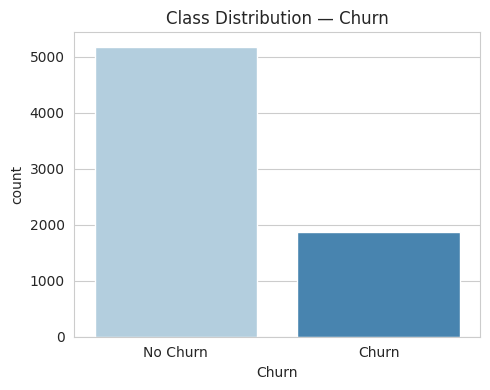

In [5]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(4))

plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df, palette="Blues")
plt.title("Class Distribution — Churn")
plt.xticks([0,1], ["No Churn", "Churn"])
plt.tight_layout(); plt.show()

# **Exploratory Data Analysis**

In [6]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "TechSupport",
            "OnlineSecurity", "PaperlessBilling", "SeniorCitizen",
            "Dependents", "Partner", "gender"]

for col in cat_cols:
    rate = df.groupby(col)["Churn"].agg(["mean", "count"])
    rate["mean"] = (rate["mean"] * 100).round(1)
    rate.columns = ["Churn Rate %", "Customers"]
    print(f"--- {col} ---")
    print(rate, "\n")

--- Contract ---
                Churn Rate %  Customers
Contract                               
Month-to-month          42.7       3875
One year                11.3       1473
Two year                 2.8       1695 

--- InternetService ---
                 Churn Rate %  Customers
InternetService                         
DSL                      19.0       2421
Fiber optic              41.9       3096
No                        7.4       1526 

--- PaymentMethod ---
                           Churn Rate %  Customers
PaymentMethod                                     
Bank transfer (automatic)          16.7       1544
Credit card (automatic)            15.2       1522
Electronic check                   45.3       2365
Mailed check                       19.1       1612 

--- TechSupport ---
                     Churn Rate %  Customers
TechSupport                                 
No                           41.6       3473
No internet service           7.4       1526
Yes                 

       tenure  MonthlyCharges  TotalCharges
Churn                                      
0       37.57           61.27       2549.91
1       17.98           74.44       1531.80

Correlation with churn:
tenure           -0.352
TotalCharges     -0.198
SeniorCitizen     0.151
MonthlyCharges    0.193
Churn             1.000
Name: Churn, dtype: float64


/tmp/ipykernel_416/2785471394.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax[1], palette="Blues")


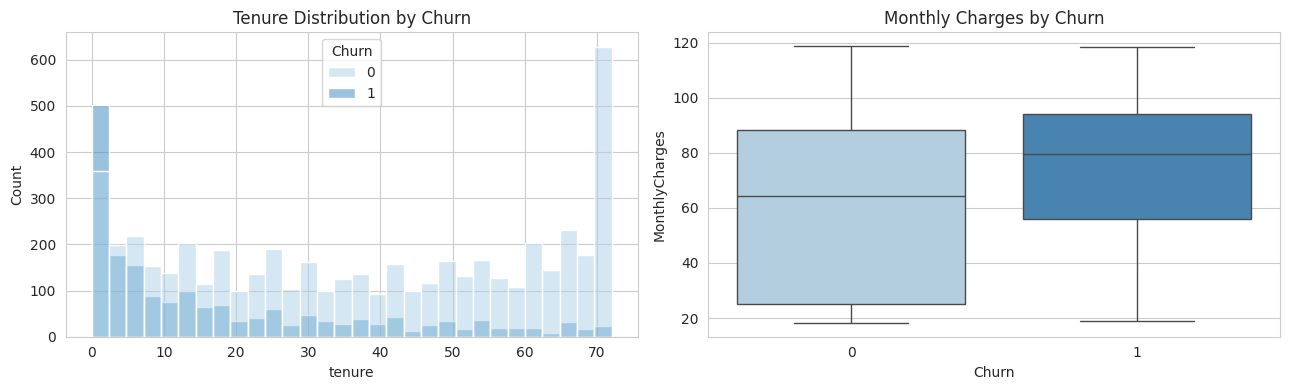

In [8]:
print(df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].mean().round(2))

num = ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen","Churn"]
print("\nCorrelation with churn:")
print(df[num].corr()["Churn"].sort_values().round(3))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, ax=ax[0], palette="Blues")
ax[0].set_title("Tenure Distribution by Churn")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax[1], palette="Blues")
ax[1].set_title("Monthly Charges by Churn")
plt.tight_layout(); plt.show()

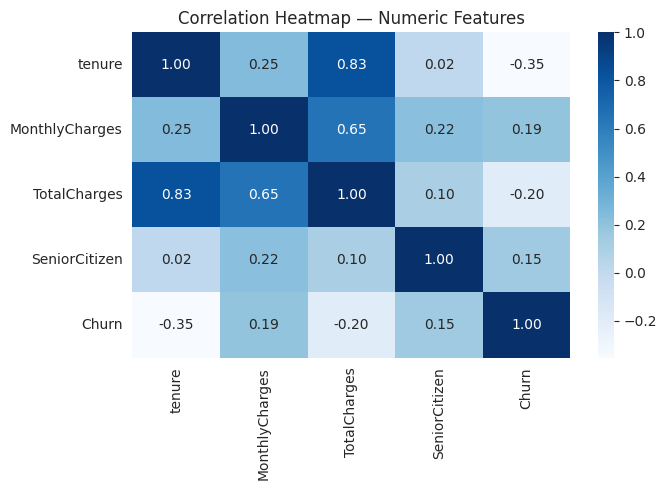

In [9]:
plt.figure(figsize=(7,5))
sns.heatmap(df[num].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout(); plt.show()

### **EDA Findings**

**Contract type is the single clearest signal.** Month-to-month customers churn at
**42.7%**; two-year contract customers churn at just **2.8%** — a 15× difference.

**Tenure is the strongest numeric predictor** (r = −0.352). Churners average 18
months with the company versus 37.6 months for those who stay. Churn risk is
front-loaded: most departures happen early in the relationship.

**Fiber optic customers churn at 41.9%** versus 19.0% for DSL — despite fiber being
the premium product. This is counterintuitive and worth investigating: it likely
reflects either price sensitivity (fiber costs more) or service quality problems.

**Electronic check payers churn at 45.3%**, roughly triple the rate of customers on
automatic bank transfer (16.7%) or credit card (15.2%). Manual payment means a
recurring active decision to keep paying.

**Customers without add-on services churn far more** — no TechSupport 41.6%, no
OnlineSecurity 41.8%. Add-ons appear to create stickiness.

**Gender has essentially no effect** (26.9% vs 26.2%) and can be expected to
contribute nothing to the models.

# **Encoding**

In [10]:
cat_features = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_features)

# One-hot encode. drop_first=True avoids the dummy-variable trap.
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

print("\nShape before encoding:", df.shape)
print("Shape after encoding: ", df_encoded.shape)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape before encoding: (7043, 20)
Shape after encoding:  (7043, 31)


# **Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify preserves the 73/27 ratio
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Churners in test set:", y_test.sum(), "of", len(y_test))

Train: (5634, 30)  Test: (1409, 30)
Churners in test set: 374 of 1409


# **Decision Tree**

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# First: an unconstrained tree, to demonstrate why constraints are needed
tree_default = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("Unconstrained tree — depth:", tree_default.get_depth(),
      "| leaves:", tree_default.get_n_leaves())
print("Train accuracy:", round(tree_default.score(X_train, y_train), 4))
print("Test accuracy: ", round(tree_default.score(X_test, y_test), 4))

Unconstrained tree — depth: 23 | leaves: 1102
Train accuracy: 0.998
Test accuracy:  0.726


In [13]:
# Constrained tree
dt = DecisionTreeClassifier(
    max_depth=5,            # limit depth to prevent memorising the training set
    min_samples_leaf=50,    # each leaf must represent a real customer segment
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
proba_dt = dt.predict_proba(X_test)[:, 1]

print("Train accuracy:", round(dt.score(X_train, y_train), 4))
print("Test accuracy: ", round(accuracy_score(y_test, y_pred_dt), 4))
print("\n", classification_report(y_test, y_pred_dt,
                                  target_names=["No Churn","Churn"], digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_dt), 4))

Train accuracy: 0.8017
Test accuracy:  0.7928

               precision    recall  f1-score   support

    No Churn     0.8350    0.8947    0.8638      1035
       Churn     0.6367    0.5107    0.5668       374

    accuracy                         0.7928      1409
   macro avg     0.7358    0.7027    0.7153      1409
weighted avg     0.7823    0.7928    0.7850      1409

Confusion matrix:
 [[926 109]
 [183 191]]
ROC-AUC: 0.8233


# **Logistic Regression**

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Scaling matters here: TotalCharges reaches ~8,700 while dummies are 0/1.
# Pipeline keeps scaling inside the training fold — no leakage.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("\n", classification_report(y_test, y_pred_lr,
                                  target_names=["No Churn","Churn"], digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 4))

Test accuracy: 0.807

               precision    recall  f1-score   support

    No Churn     0.8510    0.8937    0.8718      1035
       Churn     0.6584    0.5668    0.6092       374

    accuracy                         0.8070      1409
   macro avg     0.7547    0.7303    0.7405      1409
weighted avg     0.7998    0.8070    0.8021      1409

Confusion matrix:
 [[925 110]
 [162 212]]
ROC-AUC: 0.8418


# **Model Comparison**

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

def metrics(y_true, pred, proba):
    return {
        "Accuracy":  accuracy_score(y_true, pred),
        "Precision (Churn)": precision_score(y_true, pred),
        "Recall (Churn)":    recall_score(y_true, pred),
        "F1 (Churn)":        f1_score(y_true, pred),
        "ROC-AUC":           roc_auc_score(y_true, proba),
    }

comparison = pd.DataFrame({
    "Decision Tree":       metrics(y_test, y_pred_dt, proba_dt),
    "Logistic Regression": metrics(y_test, y_pred_lr, proba_lr),
}).round(4)

print(comparison)
print("\nMajority-class baseline accuracy:", round((y_test == 0).mean(), 4))

                   Decision Tree  Logistic Regression
Accuracy                  0.7928               0.8070
Precision (Churn)         0.6367               0.6584
Recall (Churn)            0.5107               0.5668
F1 (Churn)                0.5668               0.6092
ROC-AUC                   0.8233               0.8418

Majority-class baseline accuracy: 0.7346


# **Class Imbalance Fix**

In [16]:
dt_bal = DecisionTreeClassifier(max_depth=5, min_samples_leaf=50,
                                class_weight="balanced", random_state=42).fit(X_train, y_train)
lr_bal = Pipeline([("scaler", StandardScaler()),
                   ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                                random_state=42))]).fit(X_train, y_train)

bal = pd.DataFrame({
    "DT (balanced)": metrics(y_test, dt_bal.predict(X_test), dt_bal.predict_proba(X_test)[:,1]),
    "LR (balanced)": metrics(y_test, lr_bal.predict(X_test), lr_bal.predict_proba(X_test)[:,1]),
}).round(4)
print(bal)

                   DT (balanced)  LR (balanced)
Accuracy                  0.7452         0.7402
Precision (Churn)         0.5128         0.5069
Recall (Churn)            0.8048         0.7861
F1 (Churn)                0.6264         0.6164
ROC-AUC                   0.8315         0.8414


### **Class Imbalance Findings**

The target is imbalanced at **73.5% / 26.5%** (about 2.8:1). Both models show the
classic symptom: recall on the minority Churn class is weak (0.51 and 0.57), meaning
**roughly half of actual churners are never flagged** — despite respectable accuracy.
This is the business-critical error, since an undetected churner is a customer lost.

As a partial fix we set `class_weight='balanced'`, which weights each class inversely
to its frequency. This is *not* a complete solution — techniques like SMOTE
oversampling or tuning the decision threshold would be the fuller treatment.

# **Feature Importances**

Top 10 features driving churn (Decision Tree):
tenure                                 0.4338
InternetService_Fiber optic            0.3633
PaymentMethod_Electronic check         0.0373
TotalCharges                           0.0343
MonthlyCharges                         0.0250
MultipleLines_Yes                      0.0240
OnlineSecurity_No internet service     0.0210
Contract_Two year                      0.0199
StreamingMovies_No internet service    0.0177
Contract_One year                      0.0087
dtype: float64


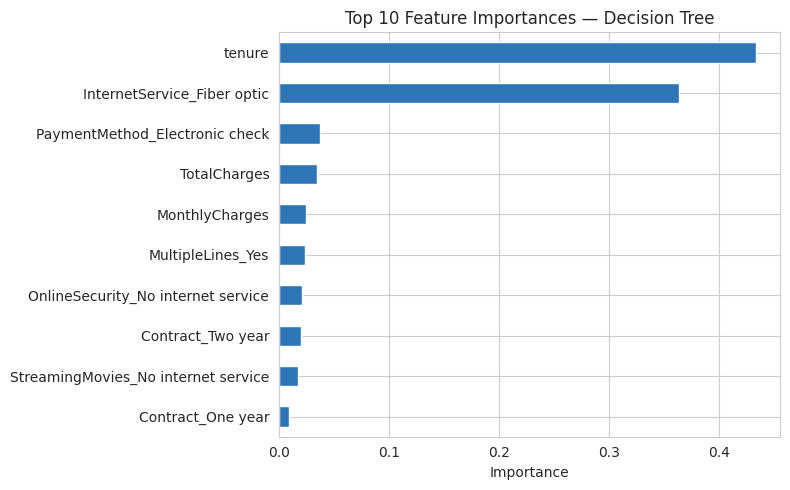

In [17]:
importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 features driving churn (Decision Tree):")
print(importances.head(10).round(4))

plt.figure(figsize=(8,5))
importances.head(10).sort_values().plot(kind="barh", color="#2E75B6")
plt.title("Top 10 Feature Importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

### **Caveat on Feature Importances**

`Contract` was the strongest signal in EDA (42.7% vs 2.8% churn), yet it barely
registers in the tree's importances. This is **not** a contradiction — it is
collinearity. Month-to-month customers average 18 months tenure while two-year
customers average 56.7 (correlation 0.56). The tree splits on `tenure` first, which
absorbs most of the contract signal, leaving little for `Contract` to add.

`feature_importances_` measures what the tree used, not *what matters in the
world*. When features are correlated, the winner takes the credit and the others
look unimportant. Logistic Regression coefficients confirm Contract's real effect:
`Contract_Two year` carries one of the strongest negative (retention) weights.
Business decisions should rest on EDA and both models together, not importances alone.

## **Business Summary**

We can now predict which customers are likely to leave with about **81% accuracy**,
and more usefully, we have identified why they leave. **The first year is the
danger zone** — customers who leave do so after an average of 18 months, versus 38
months for those who stay, so early-relationship retention is where effort pays off
most. **Three specific groups are at high risk:** month-to-month customers (43% leave,
versus just 3% on two-year contracts), fiber optic internet customers (42% leave,
more than double the DSL rate), and customers paying by electronic check (45% leave,
roughly triple those on automatic payment).

The recommended actions follow directly: offer targeted incentives to move
month-to-month customers onto annual contracts, investigate whether the fiber optic
churn problem is about pricing or service quality since it is our premium product
losing customers fastest, and promote automatic payment enrolment. One caution — the
model currently catches only about half of the customers who will actually leave, so
it should guide where to focus retention spending rather than serve as a definitive
list. Tuning it to flag more at-risk customers is a straightforward next step.